# Monthly Energy Consumption and Cost Analysis

This notebook analyzes smart home energy usage and calculates monthly electricity cost using resampling techniques.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("../data/raw/energy_data.csv")
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,85,0,36,0,121
1,2023-01-01 01:00:00,0,0,73,1023,1096
2,2023-01-01 02:00:00,0,0,43,0,43
3,2023-01-01 03:00:00,167,0,22,840,1029
4,2023-01-01 04:00:00,116,1881,50,0,2047


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   timestamp    4321 non-null   str  
 1   fridge       4321 non-null   int64
 2   ac           4321 non-null   int64
 3   lights       4321 non-null   int64
 4   microwave    4321 non-null   int64
 5   total_power  4321 non-null   int64
dtypes: int64(5), str(1)
memory usage: 202.7 KB


In [20]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,85,0,36,0,121
1,2023-01-01 01:00:00,0,0,73,1023,1096
2,2023-01-01 02:00:00,0,0,43,0,43
3,2023-01-01 03:00:00,167,0,22,840,1029
4,2023-01-01 04:00:00,116,1881,50,0,2047


In [21]:
df.set_index('timestamp', inplace=True)
df.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,85,0,36,0,121
2023-01-01 01:00:00,0,0,73,1023,1096
2023-01-01 02:00:00,0,0,43,0,43
2023-01-01 03:00:00,167,0,22,840,1029
2023-01-01 04:00:00,116,1881,50,0,2047


In [22]:
df.isnull().sum()

fridge         0
ac             0
lights         0
microwave      0
total_power    0
dtype: int64

In [23]:
df = df.ffill()

In [24]:
df['month'] = df.index.month
df.head()

,fridge,ac,lights,microwave,total_power,month
timestamp,,,,,,
2023-01-01 00:00:00,85,0,36,0,121,1
2023-01-01 01:00:00,0,0,73,1023,1096,1
2023-01-01 02:00:00,0,0,43,0,43,1
2023-01-01 03:00:00,167,0,22,840,1029,1
2023-01-01 04:00:00,116,1881,50,0,2047,1


In [25]:
monthly_usage = df.resample('ME').sum()
monthly_usage

,fridge,ac,lights,microwave,total_power,month
timestamp,,,,,,
2023-01-31,63199,149397,23554,68917,305067,744
2023-02-28,58046,112298,21964,70113,262421,1344
2023-03-31,63541,119598,24101,76100,283340,2232
2023-04-30,63638,985886,23513,54133,1127170,2880
2023-05-31,60603,1038166,23738,73085,1195592,3720
2023-06-30,59094,957216,22160,72194,1110664,4182


In [26]:
cost_per_unit = 6

monthly_usage['energy_kwh'] = monthly_usage['total_power'] / 1000
monthly_usage['monthly_cost'] = monthly_usage['energy_kwh'] * cost_per_unit

monthly_usage[['energy_kwh','monthly_cost']]

,energy_kwh,monthly_cost
timestamp,,
2023-01-31,305.067,1830.402
2023-02-28,262.421,1574.526
2023-03-31,283.340,1700.040
2023-04-30,1127.170,6763.020
2023-05-31,1195.592,7173.552
2023-06-30,1110.664,6663.984


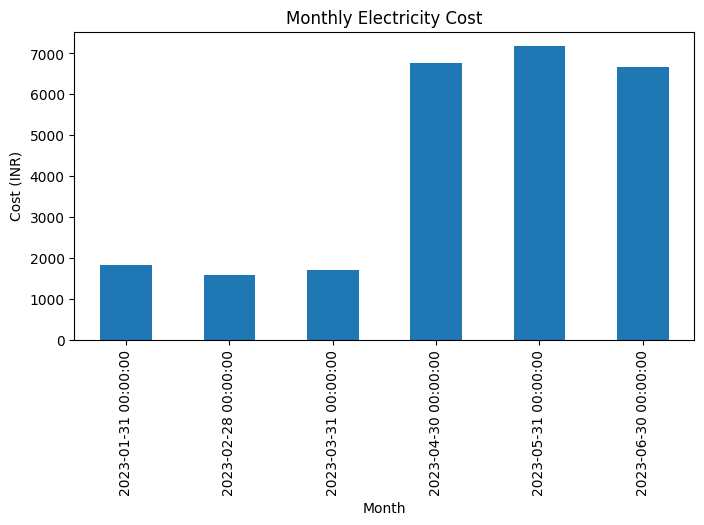

In [27]:
plt.figure(figsize=(8,4))
monthly_usage['monthly_cost'].plot(kind='bar')
plt.title("Monthly Electricity Cost")
plt.ylabel("Cost (INR)")
plt.xlabel("Month")
plt.show()